# **Copyright and Author Information**

Copyright © [2026] Docketrun Tech Private Limited. All rights reserved.

This notebook is open-sourced and available under the [MIT License](https://opensource.org/licenses/MIT).

This Colab notebook is provided for educational and informational purposes only. You are free to use, modify, and distribute it, provided that proper attribution is given.

**Disclaimer:** The information in this notebook is provided "as is," without warranty of any kind. The authors or the company do not accept any responsibility for errors or omissions in the content.

---

Author: Yahiya Mulla

# INTRODUCTION
---

## What are we building?

In this notebook, we will build a **complete end-to-end RAG system**.

RAG stands for **Retrieval-Augmented Generation**.

This means our AI will not answer only from its training.  
It will first **search useful information from an uploaded document**, and then use that information to generate a better answer.

---

## What problem are we solving?

A normal AI model can give general answers, but it may not know the exact content of **our own document**.

So the problem is:

**How can an AI answer questions from a document we upload?**

This is where RAG helps.

---

## What will you understand by the end?

By the end of this notebook, you will understand:

- why normal LLM answers are often **generic**
- how **RAG improves answer quality**
- how **retrieval + generation** work together
- how **ReAct** adds a simple **reasoning loop**
- how **agentic AI** begins with systems that can **use tools**

---

## In simple words

We are moving from:

**AI that only answers**  
to  
**AI that can look up information before answering**

And that is the first step toward more capable, tool-using AI systems.

---

## Goal of this notebook

By the end, you will have a working system where:

1. a document is uploaded  
2. the system reads and stores it  
3. relevant information is retrieved  
4. the AI answers based on that document

---

# PHASE 1: OFFLINE KNOWLEDGE PREPARATION

This entire phase is preparation of the knowledge base.

## STEP 1: DATA SOURCES
In this step, we upload a file such as a **PDF** that will act as the **knowledge source** for the AI. This file becomes the **source of truth**, but the AI cannot understand it automatically.

In [ ]:
# ------------------------------------------------------------
# Upload a PDF from your local system into Google Colab
# ------------------------------------------------------------
# What this cell does:
# 1. Creates a fixed folder named "build_your_rag"
# 2. Lets you upload a PDF from your local system
# 3. Saves it with one common name every time
# 4. If an old file already exists, it shows a warning and replaces it
# ------------------------------------------------------------

import os
from google.colab import files

# -----------------------------
# 1) Define folder and file name
# -----------------------------
TARGET_FOLDER = "/content/build_your_rag"
COMMON_FILE_NAME = "source_document.pdf"   # You can change this if needed
TARGET_PATH = os.path.join(TARGET_FOLDER, COMMON_FILE_NAME)

# -----------------------------------------
# 2) Create the target folder if not present
# -----------------------------------------
os.makedirs(TARGET_FOLDER, exist_ok=True)
print(f"Folder ready: {TARGET_FOLDER}")

# -----------------------------
# 3) Ask user to upload a PDF
# -----------------------------
print("\nPlease upload one PDF file from your local system.")
uploaded = files.upload()

# ----------------------------------------
# 4) Basic validation: check file selected
# ----------------------------------------
if not uploaded:
    print("No file was uploaded.")
else:
    # Get the first uploaded file
    original_file_name = list(uploaded.keys())[0]
    file_data = uploaded[original_file_name]

    # -----------------------------------
    # 5) Validate that it is a PDF file
    # -----------------------------------
    if not original_file_name.lower().endswith(".pdf"):
        print(f"Error: '{original_file_name}' is not a PDF file. Please upload a .pdf file only.")
    else:
        # ---------------------------------------------------------
        # 6) Warn the user if the file already exists and replace it
        # ---------------------------------------------------------
        if os.path.exists(TARGET_PATH):
            print(f"Warning: '{COMMON_FILE_NAME}' already exists in '{TARGET_FOLDER}'.")
            print("Old file will be replaced with the newly uploaded file.\n")

        # -----------------------------
        # 7) Save the uploaded PDF file
        # -----------------------------
        with open(TARGET_PATH, "wb") as f:
            f.write(file_data)

        # -----------------------------
        # 8) Final success message
        # -----------------------------
        print("Upload successful.")
        print(f"Original file name : {original_file_name}")
        print(f"Stored file name   : {COMMON_FILE_NAME}")
        print(f"Saved at           : {TARGET_PATH}")

## STEP 2: DOCUMENT PROCESSING
In this step, the uploaded PDF is converted into clean, machine-readable text. From PDF, text is extracted and cleaned. This stage does not make the system intelligent yet. It only prepares the raw content so it can be used later for retrieval.

### Objective
Convert the uploaded PDF into **clean, readable text**.

### What happens here?
- Read the PDF page by page
- Extract text from each page
- Clean broken spaces and extra newlines
- Show a readable preview

### Expected outcome
By the end of this step, we should be able to see:
- first page text
- extracted page count
- cleaned content preview


### 2.1 Install and Import Required Library

In [ ]:
# ------------------------------------------------
# Install and import the required library
# ------------------------------------------------
# We use pypdf to read the PDF file
# and re for simple text cleaning.

!pip install pypdf

import os
import re
from pypdf import PdfReader

### 2.2 Define File Path

In [ ]:
# ------------------------------------------------
# Define the PDF file path
# ------------------------------------------------
# This should match the file path used in the upload step.

BASE_FOLDER = "/content/build_your_rag"
PDF_FILE_PATH = os.path.join(BASE_FOLDER, "source_document.pdf")

print("PDF file path set to:")
print(PDF_FILE_PATH)

### 2.3 Create a Simple Text Cleaning Function

In [ ]:
# ------------------------------------------------
# Create a simple text cleaning function
# ------------------------------------------------
# PDF text extraction can contain:
# - extra spaces
# - too many line breaks
# - broken formatting
#
# This function makes the text easier to read.

def clean_text(text: str) -> str:
    """
    Clean extracted PDF text in a simple beginner-friendly way.
    """
    if not text:
        return ""

    # Replace multiple spaces/tabs with one space
    text = re.sub(r"[ \t]+", " ", text)

    # Remove too many blank lines
    text = re.sub(r"\n\s*\n+", "\n\n", text)

    # Remove extra spaces around line breaks
    text = re.sub(r" *\n *", "\n", text)

    # Final trim
    text = text.strip()

    return text

print("Text cleaning function is ready.")

### 2.4 Extract Text Page by Page

In [ ]:
# ---------------------------------------------------
# Read the PDF and extract text page by page
# ---------------------------------------------------
# In this step, we:
# 1. Check whether the PDF exists
# 2. Read it page by page
# 3. Store both raw text and cleaned text

pdf_pages_raw = []
pdf_pages_clean = []

if not os.path.exists(PDF_FILE_PATH):
    print("PDF file not found.")
    print("Please run the upload step first and make sure the file exists.")
else:
    print("PDF found. Starting extraction...\n")

    reader = PdfReader(PDF_FILE_PATH)
    total_pages = len(reader.pages)

    print(f"Total pages found: {total_pages}\n")

    for page_number, page in enumerate(reader.pages, start=1):
        raw_text = page.extract_text()

        # Handle cases where a page may not return text
        if raw_text is None:
            raw_text = ""

        cleaned_text = clean_text(raw_text)

        pdf_pages_raw.append(raw_text)
        pdf_pages_clean.append(cleaned_text)

    print("PDF text extraction completed successfully.")

### 2.5 Print Page Raw Text

In [ ]:
# -------------------------------------
# Show the page raw text
# -------------------------------------
# This helps to see what the extracted text
# looks like before cleaning.

page_no = 2

if len(pdf_pages_raw) > 0 and page_no <= len(pdf_pages_raw):
    print("RAW TEXT PREVIEW of Page no: {0} - Max 3000 characters".format(page_no) )
    print("-" * 50)
    print(pdf_pages_raw[page_no-1][:3000])  # show only first 3000 characters
else:
    print("No pages were extracted.")

### 2.6 Print Page cleaned text

In [ ]:
# -------------------------------------
# Show the page cleaned text
# -------------------------------------
# This helps students compare raw text vs cleaned text.

page_no = 2

if len(pdf_pages_clean) > 0 and page_no <= len(pdf_pages_clean):
    print("CLEANED TEXT PREVIEW of Page no: {0} - Max 3000 characters".format(page_no) )
    print("-" * 50)
    print(pdf_pages_clean[page_no-1][:3000])  # show only first 3000 characters
else:
    print("No pages were extracted.")

### 2.7 Combine All Pages into One Final Text

In [ ]:
# --------------------------------------------------------------
# Combine all cleaned pages into one full document text
# --------------------------------------------------------------
# Later in RAG, we usually work with the full document text.
# So here we combine all cleaned pages into one variable.

full_document_text = "\n\n".join(pdf_pages_clean)

print("Full document text is ready.")
print(f"Total characters in cleaned document: {len(full_document_text)}")

### 2.8 Show Final Cleaned Content Preview

In [ ]:
# Show a preview of the final cleaned document
# -----------------------------------------------------
# This gives students a quick look at the machine-readable text
# that will later be used for retrieval.

print("CLEANED DOCUMENT PREVIEW")
print("-" * 50)
print(full_document_text[:5000])  # show only first 5000 characters

## STEP 3: CHUNKING

### Objective
Break the large document text into **smaller meaningful chunks**.

### What students do
For the uploaded PDF:
- split the cleaned text into chunk windows

A large document is difficult to search as **one huge block**.

Chunking helps:
- preserve meaning
- improve retrieval precision
- fit useful context into the prompt later

### Important concept
- **Large chunk** = may contain too much noise  
- **Tiny chunk** = may lose the full meaning  
- **Overlap** = helps preserve continuity between chunks  

### 3.1 Define Chunk Settings

In [ ]:
# --------------------------------------
# Define chunk size and overlap
# --------------------------------------
# chunk_size     = how much text goes into one chunk
# chunk_overlap  = how much text is repeated in the next chunk
#
# Why overlap?
# It helps keep continuity between chunks so meaning is not lost.

chunk_size = 1000      # number of characters per chunk
chunk_overlap = 200    # repeated characters between nearby chunks

print("Chunk settings:")
print(f"Chunk size    : {chunk_size}")
print(f"Chunk overlap : {chunk_overlap}")

### 3.2 Create Chunking Function

In [ ]:
# ------------------------------------------
# Create a simple chunking function
# ------------------------------------------
# This function splits one large text into smaller windows.
# We use character-based chunking here because it is easy to understand.
#
# Example:
# Chunk 1 = characters 0 to 1000
# Chunk 2 = characters 800 to 1800
# The repeated part is the overlap.

def chunk_text(text, chunk_size=1000, chunk_overlap=200):
    """
    Split a large text into overlapping chunks.

    Parameters:
        text (str): full document text
        chunk_size (int): size of each chunk
        chunk_overlap (int): overlap between chunks

    Returns:
        list[str]: list of text chunks
    """
    chunks = []

    # Safety check
    if not text or not text.strip():
        return chunks

    start = 0
    text_length = len(text)

    while start < text_length:
        end = start + chunk_size
        chunk = text[start:end].strip()

        if chunk:
            chunks.append(chunk)

        # Move forward, but keep some overlap
        start += chunk_size - chunk_overlap

    return chunks

print("Chunking function is ready.")

### 3.4 Split the Document into Chunks

In [ ]:
# -----------------------------------------------
# Split the cleaned document into chunks
# -----------------------------------------------
# Here we apply the chunking function to the full document text.

document_chunks = chunk_text(
    text=full_document_text,
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)

print("Chunking completed.")
print(f"Total chunks created: {len(document_chunks)}")

### 3.5 Show Chunk Lengths

In [ ]:
# ----------------------------------------------
# Show the size of the first few chunks
# ----------------------------------------------
# This helps us to see that chunks are smaller units of the document.

preview_count = min(5, len(document_chunks))

for i in range(preview_count):
    print(f"Chunk {i + 1} length: {len(document_chunks[i])} characters")

### 3.6 Simple Overlap Demonstration

In [ ]:
# --------------------------------------------------------
# Demonstrate overlap between chunk 1 and chunk 2
# --------------------------------------------------------
# This helps students understand how overlap preserves continuity.

if len(document_chunks) >= 2:
    print("END OF CHUNK 1")
    print("-" * 40)
    print(document_chunks[0][-300:])   # last 300 characters of chunk 1

    print("\nSTART OF CHUNK 2")
    print("-" * 40)
    print(document_chunks[1][:300])    # first 300 characters of chunk 2
else:
    print("Not enough chunks to demonstrate overlap.")

### 3.7 Store Chunks in a Simple Structure

In [ ]:
# ------------------------------------
# Store chunks with chunk IDs
# ------------------------------------
# This makes the chunks easier to manage later in retrieval steps.

chunk_records = []

for i, chunk in enumerate(document_chunks):
    chunk_records.append({
        "chunk_id": i,
        "text": chunk
    })

print("Chunk records created successfully.")
print("Example record:\n")
print(chunk_records[0] if chunk_records else "No chunk records found.")

## STEP 4: CHUNK EMBEDDING

### Objective
Convert each text chunk into a **vector**.

### What we will do
- pass chunk text into an embedding model
- get numeric vectors

### What is **vector** ?
A vector is a mathematical representation of data (like text, images, or audio) converted into a long list of numbers.

These numbers represent the semantic meaning of the content rather than just the literal words.

This is how the system can understand that these phrases are similar:

- “change password”
- “reset login credentials”

Even though the exact words are different, the meaning is close.

### Important learning point
- **Embedding is not generation**
- **Embedding is semantic representation**


### 4.1 Install and Import Required Libraries

In [ ]:
# --------------------------------------------------
# Install and import the required libraries
# --------------------------------------------------
# We use:
# - sentence-transformers to convert text into embeddings
# - numpy for simple numeric handling

!pip uninstall -y torch transformers
!pip install torch==2.1.0+cpu --index-url https://download.pytorch.org/whl/cpu
!pip install sentence-transformers

import numpy as np
from sentence_transformers import SentenceTransformer

### 4.2 Check Whether Chunks Are Ready

In [ ]:
# ----------------------------------------------
# Make sure chunk records are available
# ----------------------------------------------
# These chunk records should come from STEP 3.
# Each record contains:
# - chunk_id
# - text
#
# If this variable is missing, we should run STEP 3 first.

try:
    print("Chunk records found.")
    print(f"Total chunks available: {len(chunk_records)}")

    if len(chunk_records) > 0:
        print("\nFirst chunk record preview:")
        print("-" * 50)
        print("Chunk ID:", chunk_records[0]["chunk_id"])
        print("Chunk Text Preview:")
        print(chunk_records[0]["text"][:500])
except NameError:
    print("chunk_records was not found.")
    print("Please run STEP 3 first to create chunk records from the document.")

### 4.3 Load the Embedding Model

In [ ]:
# --------------------------------
# Load an embedding model
# --------------------------------
# This model converts text into vectors.
# Each text chunk will become a list of numbers.
#
# Important note:
# This model does NOT generate answers.
# It only converts meaning into numbers.

embedding_model_name = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(embedding_model_name)

print("Embedding model loaded successfully.")
print("Model name:", embedding_model_name)

### 4.4 Extract Chunk Text from Chunk Records

In [ ]:
# ----------------------------------------------
# Extract chunk text from chunk records
# ----------------------------------------------
# The embedding model only needs text.
# So here we take only the "text" field from each chunk record.

chunk_texts = [record["text"] for record in chunk_records]

print("Chunk texts prepared for embedding.")
print(f"Total chunk texts: {len(chunk_texts)}")

if len(chunk_texts) > 0:
    print("\nFirst chunk text preview:")
    print("-" * 50)
    print(chunk_texts[0][:500])

### 4.5 Convert Chunk Text into Embeddings

In [ ]:
# ----------------------------------------------
# Convert chunk text into embeddings
# ----------------------------------------------
# Here we pass all chunk texts into the embedding model.
# The model returns one numeric vector for each chunk.

chunk_embeddings = embedding_model.encode(chunk_texts)

print("Chunk embedding completed successfully.")
print(f"Total chunk vectors created: {len(chunk_embeddings)}")

### 4.6 Inspect the First Embedding Vector

In [ ]:
# ----------------------------------------------
# Inspect the first embedding vector
# ----------------------------------------------
# This helps us to understand what an embedding looks like.

if len(chunk_embeddings) > 0:
    first_vector = chunk_embeddings[0]

    print("First chunk embedding created successfully.")
    print(f"Vector type      : {type(first_vector)}")
    print(f"Vector dimension : {len(first_vector)}")

    print("\nFirst 20 values of the first vector:")
    print(first_vector[:20])
else:
    print("No embeddings were created.")

### 4.7 Show Chunk Text and Matching Vector Together

In [ ]:
# ----------------------------------------------
# Show one chunk and its matching vector
# ----------------------------------------------
# This helps us to connect:
# text meaning -> numeric representation

if len(chunk_records) > 0 and len(chunk_embeddings) > 0:
    print("CHUNK TEXT PREVIEW")
    print("-" * 50)
    print(chunk_records[0]["text"][:400])

    print("\nMATCHING VECTOR PREVIEW")
    print("-" * 50)
    print(chunk_embeddings[0][:20])
else:
    print("Chunk records or embeddings are missing.")

### 4.8 Add Embeddings Back into Chunk Records

In [ ]:
# ----------------------------------------------
# Add embeddings back into chunk records
# ----------------------------------------------
# Now each chunk record will contain:
# - chunk_id
# - text
# - embedding
#
# This is useful because later retrieval can work from one clean structure.

for i, embedding in enumerate(chunk_embeddings):
    chunk_records[i]["embedding"] = embedding

print("Embeddings added to chunk records successfully.")

if len(chunk_records) > 0:
    print("\nUpdated example record:")
    print("Chunk ID:", chunk_records[0]["chunk_id"])
    print("Text Preview:", chunk_records[0]["text"][:200])
    print("Embedding Preview:", chunk_records[0]["embedding"][:10])

### 4.9 Quick Final Structure Check

In [ ]:
# ----------------------------------------------
# Final structure check
# ----------------------------------------------
# This confirms that chunk_records now contains everything we need.

print("Final chunk record keys:")

if len(chunk_records) > 0:
    print(chunk_records[0].keys())
else:
    print("No chunk records found.")

### 4.10 Demonstrateing Semantic Similarity

In [ ]:
# ----------------------------------------------
# Show how similar meanings get similar vectors
# ----------------------------------------------
# We compare:
# 1. Two similar phrases
# 2. One unrelated phrase
#
# This helps us to understand why embeddings are useful.

import numpy as np

sample_sentences = [
    "Hey Yahiya",
    "Hey all",
    "How are you all doing ?"
]

sample_vectors = embedding_model.encode(sample_sentences)

def cosine_similarity(vec1, vec2):
    """
    Compute cosine similarity between two vectors.
    Higher value means more similar meaning.
    """
    vec1 = np.array(vec1)
    vec2 = np.array(vec2)
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

sim_1_2 = cosine_similarity(sample_vectors[0], sample_vectors[1])
sim_1_3 = cosine_similarity(sample_vectors[0], sample_vectors[2])

print("Sentence 1:", sample_sentences[0])
print("Sentence 2:", sample_sentences[1])
print("Sentence 3:", sample_sentences[2])

print("\nSimilarity between Sentence 1 and Sentence 2:")
print(sim_1_2)

print("\nSimilarity between Sentence 1 and Sentence 3:")
print(sim_1_3)

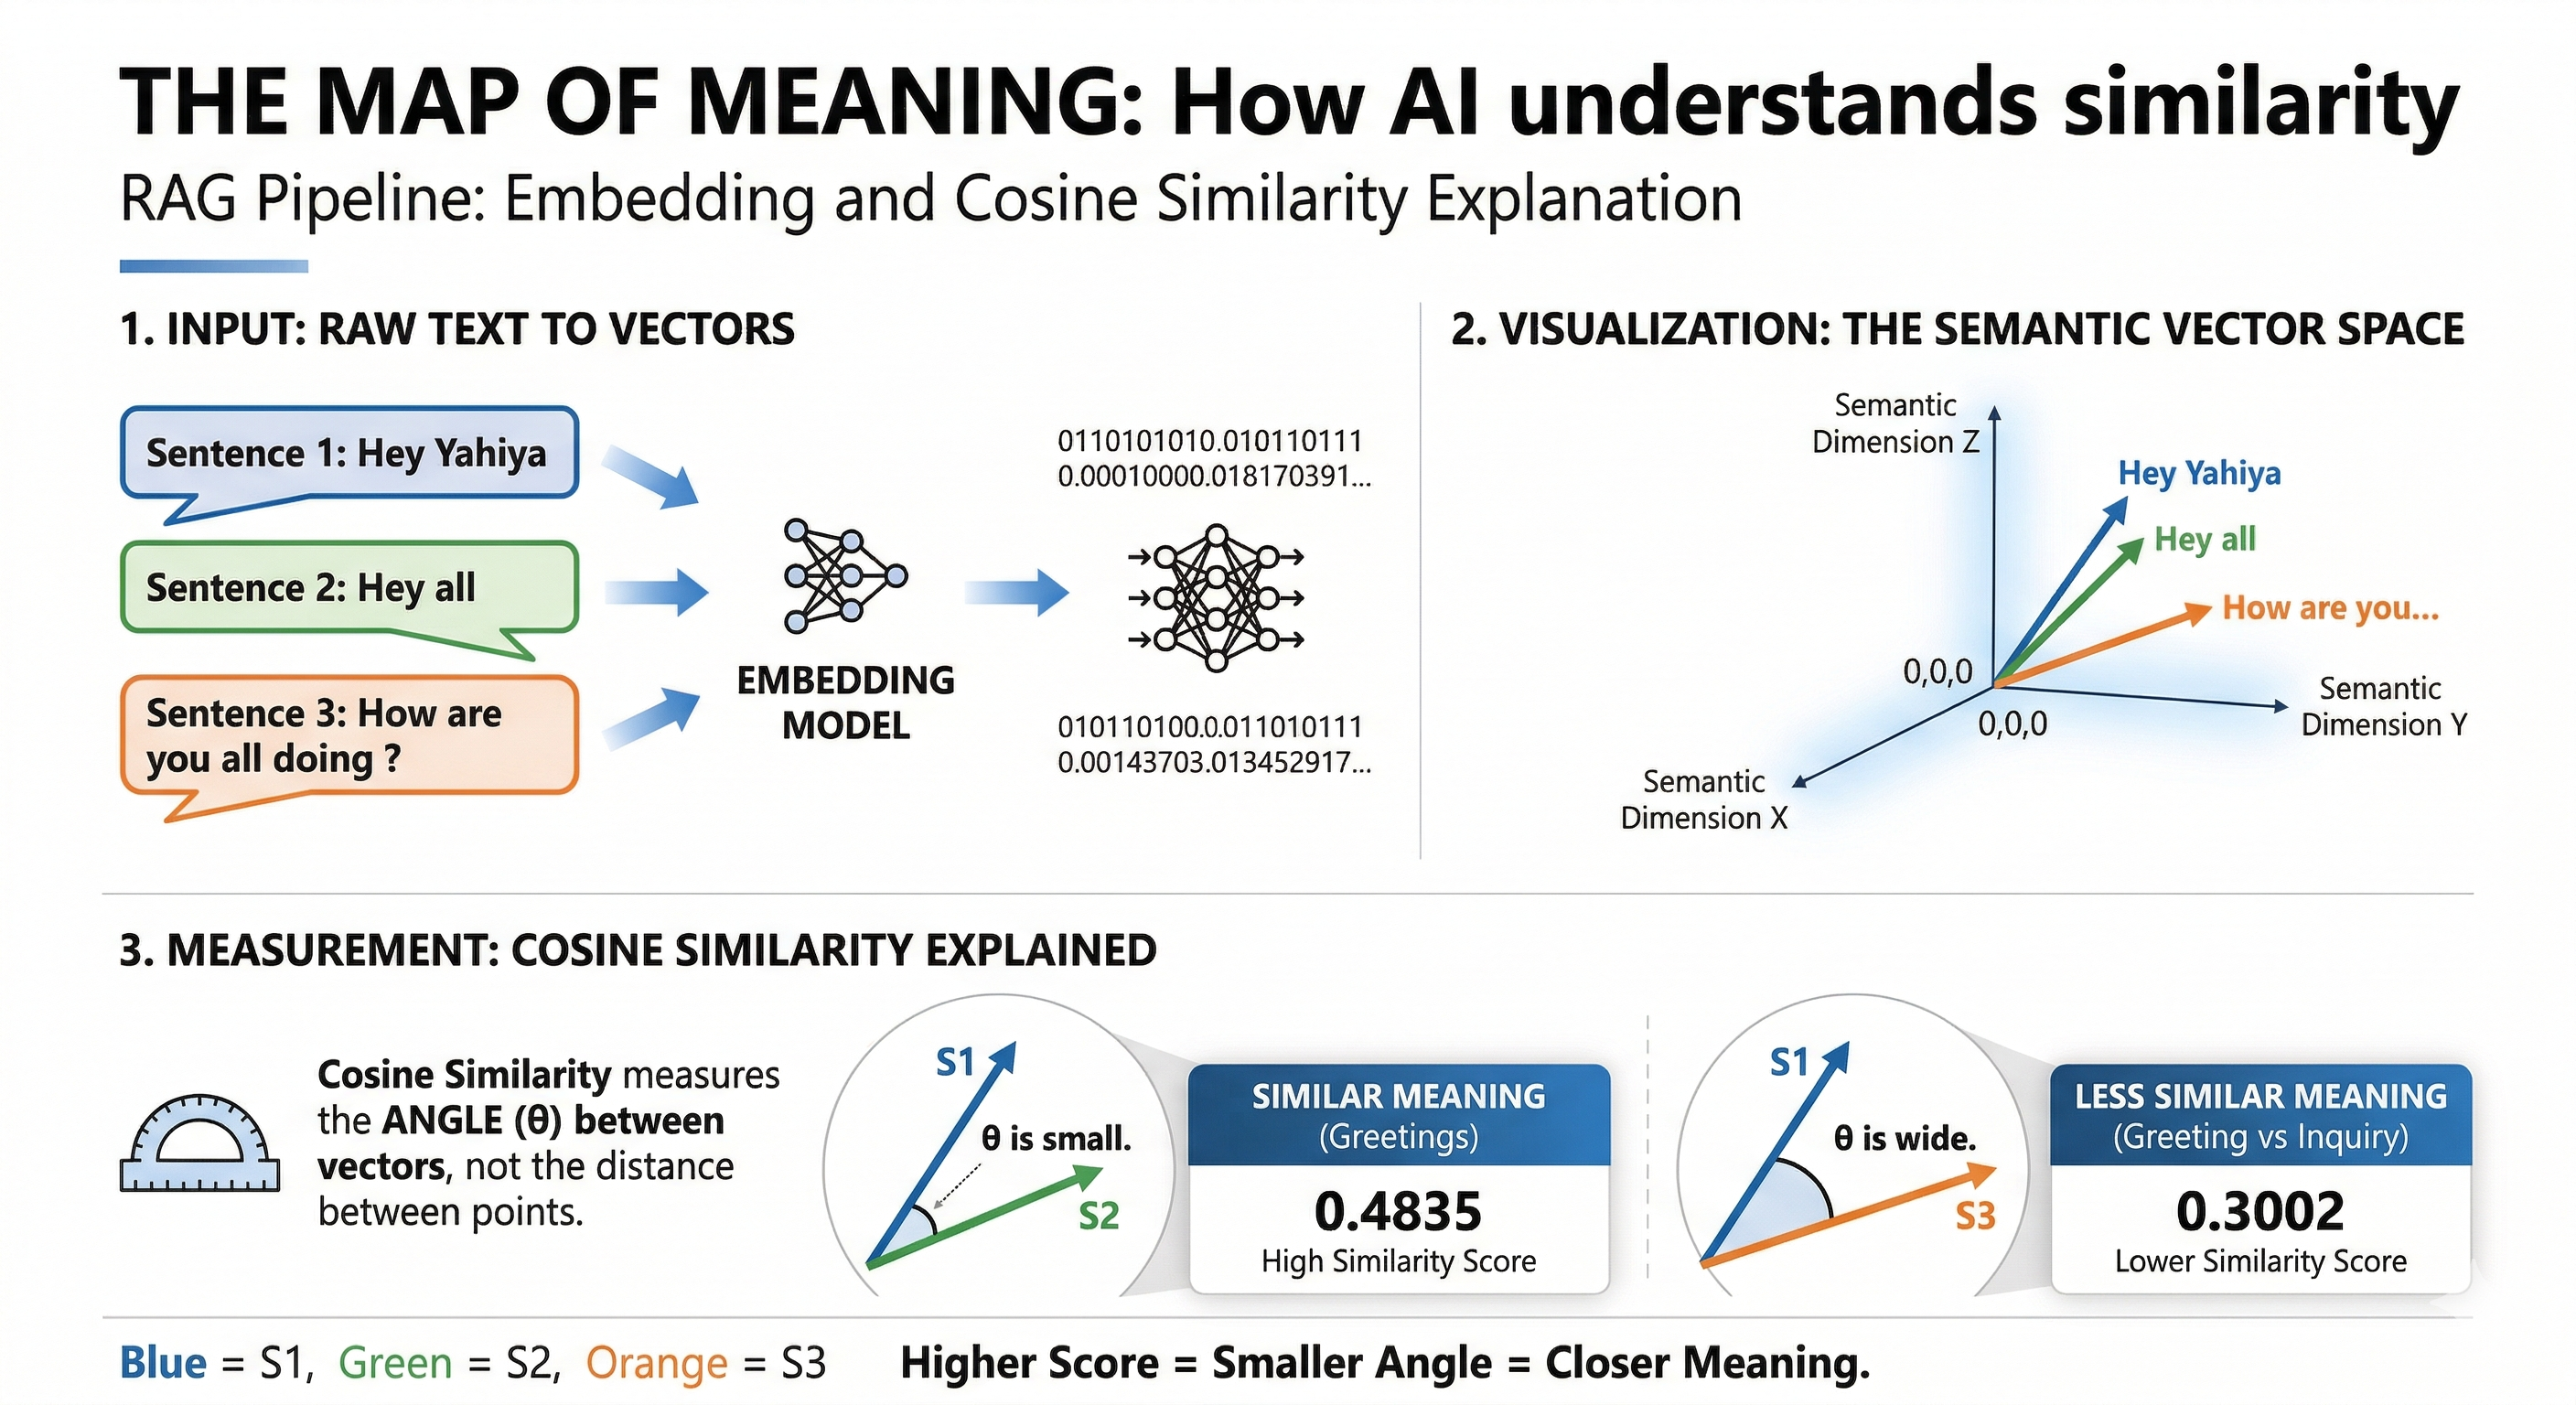

## STEP 5: VECTOR DATABASE / INDEX

### Objective
Store chunk embeddings in a **searchable vector index**.

### What we will do
- create a **FAISS index**
- add chunk embeddings into it

This is the **memory/search layer** of the RAG pipeline.

Once chunk text is converted into embeddings, those vectors are stored in a structure that supports **fast similarity search**.


### 5.1 Install and Import FAISS

In [ ]:
# ----------------------------------------------
# Install and import FAISS
# ----------------------------------------------
# FAISS is a library used for fast vector search.
# It helps us store embeddings in a searchable index.

!pip install faiss-cpu

import faiss
import numpy as np

### 5.2 Check Whether Embedded Chunk Records Are Ready

In [ ]:
# ----------------------------------------------
# Check whether embedded chunk records are ready
# ----------------------------------------------
# Before creating the vector index, we must make sure:
# 1. chunk_records exists
# 2. each chunk record already has an embedding

try:
    print("Chunk records found.")
    print(f"Total chunk records: {len(chunk_records)}")

    if len(chunk_records) > 0:
        print("\nFirst chunk record keys:")
        print(chunk_records[0].keys())

        if "embedding" in chunk_records[0]:
            print("\nEmbeddings are available. Ready to build the index.")
        else:
            print("\n'embedding' field not found in chunk_records.")
            print("Please run STEP 4 first.")
except NameError:
    print("chunk_records was not found.")
    print("Please run STEP 3 and STEP 4 first.")

### 5.3 Extract Embeddings into a Matrix

In [ ]:
# ----------------------------------------------
# Extract embeddings into one matrix
# ----------------------------------------------
# FAISS expects embeddings in a NumPy array.
# So here we collect all chunk embeddings into one matrix.

embedding_matrix = np.array(
    [record["embedding"] for record in chunk_records],
    dtype="float32"
)

print("Embedding matrix created successfully.")
print(f"Matrix shape: {embedding_matrix.shape}")

### 5.4 Understand the Shape of the Embeddings

In [ ]:
# ----------------------------------------------
# Show number of chunks and embedding dimension
# ----------------------------------------------
# Shape format:
# (number_of_chunks, embedding_dimension)

num_chunks, embedding_dimension = embedding_matrix.shape

print("Vector data summary")
print("-" * 40)
print(f"Number of chunks stored      : {num_chunks}")
print(f"Embedding dimension per chunk: {embedding_dimension}")

### 5.5 Create the FAISS Index

In [ ]:
# ----------------------------------------------
# Create the FAISS index
# ----------------------------------------------
# We use IndexFlatL2, which is a simple FAISS index.
# It compares vectors based on distance.
#
# This is a good beginner-friendly starting point.

faiss_index = faiss.IndexFlatL2(embedding_dimension)

print("FAISS index created successfully.")
print("Index type: IndexFlatL2")

### 5.6 Add Embeddings into the FAISS Index

In [ ]:
# ----------------------------------------------
# Add embeddings into the FAISS index
# ----------------------------------------------
# Now we store all chunk vectors inside the index.
# This makes them searchable later.

faiss_index.add(embedding_matrix)

print("Embeddings added to FAISS index successfully.")

### 5.7 Confirm the Index is Ready

In [ ]:
# ----------------------------------------------
# Confirm the index is ready
# ----------------------------------------------
# ntotal tells us how many vectors are stored inside the index.

print("FAISS index is ready.")
print(f"Total vectors stored in index: {faiss_index.ntotal}")

### 5.8 Final Readiness Check

In [ ]:
# ----------------------------------------------
# Final readiness check
# ----------------------------------------------
# This is a simple summary to show us that
# the searchable memory layer is now ready.

print("STEP 5 COMPLETE")
print("-" * 40)
print(f"Chunks available         : {len(chunk_records)}")
print(f"Embedding matrix shape   : {embedding_matrix.shape}")
print(f"Vectors stored in FAISS  : {faiss_index.ntotal}")
print("Searchable vector index is ready.")

# PHASE 2: ONLINE QUESTION ANSWERING

So far, we prepared the document for retrieval.

Now the actual question-answering starts.

In this phase, the system will:
1. take a user question
2. convert the question into an embedding
3. search the vector index
4. retrieve relevant chunks
5. use those chunks to generate an answer

## STEP 6: USER QUERY

### Objective
Take a **natural-language question** from the user.

### Example questions

If the PDF is a handbook:
- What is the attendance policy?
- What happens if attendance is low?
- Is there a revaluation process?

If the PDF is a policy or manual:
- What safety procedure is described?
- What does the document say about leave approval?

The user does **not** search the document manually.  
They simply ask in natural language.


### 6.1 Get the input from the user

In [ ]:
# ----------------------------------------------
# Create a user question
# ----------------------------------------------
# This is the question the user wants to ask the document.
# We can change this text and try different questions.

user_query = "What will be the aftermath ?"

print("User query captured successfully.")
print("Question:")
print(user_query)

### 6.2 Basic Query Cleaning

In [ ]:
# ----------------------------------------------
# Clean the user query
# ----------------------------------------------
# This is a simple cleaning step.
# It removes extra spaces and makes the query neat.

user_query = user_query.strip()

print("Cleaned user query:")
print(user_query)

## STEP 7: QUERY EMBEDDING

### Objective
Convert the user’s question into a **vector**.

### What we do
- use the **same embedding model**
- embed the user question

Now both:
- **document chunks**
- **user question**

exist in the same **semantic space**.

That means the system can compare:
- question meaning
- chunk meaning

instead of only matching exact words.


### 7.1 Check Whether the User Query Is Ready

In [ ]:
# ----------------------------------------------
# Check whether the user query is ready
# ----------------------------------------------
# This query should come from STEP 6.
# If it is missing, run the previous step first.

try:
    if user_query:
        print("User query found.")
        print("Question:")
        print(user_query)
    else:
        print("User query is empty. Please set a valid question first.")
except NameError:
    print("user_query was not found.")
    print("Please run STEP 6 first.")

### 7.2 Check Whether the Embedding Model Is Ready

In [ ]:
# ----------------------------------------------
# Check whether the embedding model is ready
# ----------------------------------------------
# We use the same embedding model that was used for document chunks.
# This is very important because both question and chunks must be
# represented in the same semantic space.

try:
    embedding_model
    print("Embedding model is available.")
    print("Model is ready to embed the user query.")
except NameError:
    print("embedding_model was not found.")
    print("Please run STEP 4 first to load the embedding model.")

### 7.3 Convert the User Query into an Embedding

In [ ]:
# ----------------------------------------------
# Convert the user query into a vector
# ----------------------------------------------
# Here we pass the user question into the embedding model.
# The result will be a numeric vector representing the meaning
# of the question.

query_embedding = embedding_model.encode(user_query)

print("Query embedding created successfully.")

### 7.4 Inspect the Query Embedding

In [ ]:
# ----------------------------------------------
# Inspect the query embedding
# ----------------------------------------------
# This helps us to understand that the question is now
# represented as numbers, just like the document chunks.

print("Query embedding details")
print("-" * 40)
print("Vector type      :", type(query_embedding))
print("Vector dimension :", len(query_embedding))

print("\nFirst 20 values of the query vector:")
print(query_embedding[:20])

### 7.5 Convert Query Embedding into FAISS Search Format

In [ ]:
# ----------------------------------------------
# Prepare the query vector for FAISS
# ----------------------------------------------
# FAISS expects a 2D NumPy array of type float32.
# So we reshape the query embedding into the correct format.

import numpy as np

query_vector = np.array([query_embedding], dtype="float32")

print("Query vector prepared for FAISS search.")
print("Query vector shape:", query_vector.shape)

### 7.6 Compare Query Vector Shape with Chunk Vector Shape

In [ ]:
# ----------------------------------------------
# Confirm semantic compatibility
# ----------------------------------------------
# This shows that the question vector and chunk vectors
# have the same embedding dimension.
# That is why similarity search is possible.

print("Semantic space check")
print("-" * 40)

print("Query vector dimension :", query_vector.shape[1])

try:
    print("Chunk vector dimension :", len(chunk_records[0]["embedding"]))

    if query_vector.shape[1] == len(chunk_records[0]["embedding"]):
      print("\nBoth are in the same vector space and can now be compared.")
    else:
      print("ERROR - Both are not same")
except Exception:
    print("Could not verify chunk embedding dimension.")
    print("Please make sure STEP 4 completed successfully.")

### 7.7 Final Readiness Check

In [ ]:
# ----------------------------------------------
# Final readiness check
# ----------------------------------------------
# This confirms that the user question is now ready
# for similarity search in the vector index.

print("STEP 7 COMPLETE")
print("-" * 40)
print("User question:", user_query)
print("Query vector shape:", query_vector.shape)
print("The question is now embedded and ready for retrieval.")

## STEP 8: RETRIEVER

### Objective
Find the **top-k most relevant chunks** for the user’s question.

### What we will do
- run vector similarity search
- get top matching chunks
- display them

This is one of the most important parts of the RAG pipeline.

The **retriever does not answer the question**.  
It only finds the most relevant evidence from the document.


### 8.1 Check Whether Retrieval Inputs Are Ready

In [ ]:
# ----------------------------------------------
# Check whether retrieval inputs are ready
# ----------------------------------------------
# Before retrieval, we need:
# 1. faiss_index   -> searchable vector index
# 2. query_vector  -> embedded user question
# 3. chunk_records -> chunk text + embeddings + optional metadata

required_variables = ["faiss_index", "query_vector", "chunk_records"]

missing_variables = [var for var in required_variables if var not in globals()]

if len(missing_variables) == 0:
    print("All required retrieval inputs are available.")
    print("Retriever is ready.")
else:
    print("Some required variables are missing:")
    for var in missing_variables:
        print("-", var)
    print("\nPlease run the earlier steps first.")

### 8.2 Choose How Many Chunks to Retrieve

In [ ]:
# ----------------------------------------------
# Set top-k retrieval size
# ----------------------------------------------
# top_k means how many best matching chunks we want to retrieve.
# You can increase or decrease this later.

top_k = 3

print("Retriever configuration")
print("-" * 40)
print(f"Top-k chunks to retrieve: {top_k}")

The retriever usually does not know with 100% certainty that one chunk alone contains the full answer.

Sometimes:

- chunk 1 has the main rule
- chunk 2 has an exception
- chunk 3 has an important detail or condition

So choosing top_k helps decide how much evidence we want before generating the final answer.

---

if you choose a very small value like 1:

- retrieval is very focused
- less noise is included
- faster and smaller context

But:

- the system may miss supporting details
- the answer may become incomplete
- important exceptions may be lost

---

If you choose a large value like 10 or 15:

- more context is retrieved
- higher chance of including the answer somewhere
- useful for broad or complex questions

But:

- more irrelevant chunks may come in
- more noise is added
- the final prompt becomes larger
- the LLM may get distracted by less relevant text

So too much retrieval can reduce answer quality.

### 8.3 Run FAISS Similarity Search

In [ ]:
# ----------------------------------------------
# Run vector similarity search
# ----------------------------------------------
# We search the query vector inside the FAISS index.
#
# FAISS returns:
# - distances: how far each chunk is from the query
# - indices:   which chunk positions matched
#
# Since we used IndexFlatL2 earlier:
# - lower distance = better match

distances, indices = faiss_index.search(query_vector, top_k)

print("Retrieval search completed successfully.")
print("\nReturned chunk positions:")
print(indices)

print("\nReturned distances:")
print(distances)

### 8.4 Convert Raw Retrieval Output into Readable Results

In [ ]:
# ----------------------------------------------
# Build readable retrieval results
# ----------------------------------------------
# Here we convert raw FAISS output into a cleaner structure
# for display and understanding.
#
# We will show:
# - rank
# - chunk id
# - page number (if available)
# - similarity score
# - chunk text preview
#
# Note:
# FAISS returned L2 distance, not cosine similarity.
# To make classroom display easier, we create a simple match score:
#
# similarity_score = 1 / (1 + distance)
#
# This gives a score where:
# - higher is better
# - closer chunks get better scores

retrieval_results = []

for rank, (retrieved_index, distance) in enumerate(zip(indices[0], distances[0]), start=1):
    if retrieved_index == -1:
        continue

    record = chunk_records[int(retrieved_index)]

    chunk_id = record.get("chunk_id", int(retrieved_index))
    similarity_score = 1 / (1 + float(distance))

    chunk_text = record.get("text", "")
    chunk_preview = chunk_text[:400].replace("\n", " ").strip()

    retrieval_results.append({
        "rank": rank,
        "chunk_id": chunk_id,
        "similarity_score": similarity_score,
        "distance": float(distance),
        "text_preview": chunk_preview,
        "full_text": chunk_text
    })

print("Readable retrieval results prepared successfully.")
print(f"Total retrieved results: {len(retrieval_results)}")

### 8.5 Display Retrieved Chunks Clearly

In [ ]:
# ----------------------------------------------
# Display top retrieved chunks
# ----------------------------------------------
# This is the most important live output for us.
# It shows what the retriever found before any LLM answer is generated.

print("TOP RETRIEVED CHUNKS")
print("=" * 80)
print("User Question:", user_query)
print("=" * 80)

for result in retrieval_results:
    print(f"\nRANK: {result['rank']}")
    print("-" * 80)
    print(f"Chunk ID         : {result['chunk_id']}")
    print(f"Similarity Score : {result['similarity_score']:.4f}")
    print(f"FAISS Distance   : {result['distance']:.4f}")
    print("Chunk Preview    :")
    print(result["text_preview"])

### 8.6 Create Retrieved Context for the Next Step

In [ ]:
# ----------------------------------------------
# Combine retrieved chunks into one context block
# ----------------------------------------------
# In the next step, the LLM will need context.
# So here we join the top retrieved chunks into one text block.

retrieved_context = "\n\n".join(
    [result["full_text"] for result in retrieval_results]
)

print("Retrieved context created successfully.")
print(f"Total characters in retrieved context: {len(retrieved_context)}")

### 8.7 Preview the Final Retrieved Context

In [ ]:
# ----------------------------------------------
# Preview the final retrieved context
# ----------------------------------------------
# This is the evidence that will later be given to the LLM.

print("RETRIEVED CONTEXT PREVIEW")
print("-" * 80)
print(retrieved_context[:3000])

## STEP 9: PROMPT CONSTRUCTION

### Objective
Build a **grounded prompt** using the retrieved chunks.

### What we will do
Construct a prompt that contains:
- instruction
- context
- user question

### Example structure
- Answer only using the context below
- If the answer is not found, say so
- Here are the retrieved chunks
- Here is the question

This is where retrieval output is transformed into a useful input for the LLM.

Even if retrieval is good, a weak prompt can still produce poor answers.

### 9.1 Check Whether Prompt Inputs Are Ready

In [ ]:
# ----------------------------------------------
# Check whether prompt inputs are ready
# ----------------------------------------------
# Before building the final prompt, we need:
# 1. user_query         -> the user's question
# 2. retrieved_context  -> the evidence found by the retriever

required_variables = ["user_query", "retrieved_context"]

missing_variables = [var for var in required_variables if var not in globals()]

if len(missing_variables) == 0:
    print("All prompt inputs are available.")
    print("Ready to build the grounded prompt.")
else:
    print("Some required variables are missing:")
    for var in missing_variables:
        print("-", var)
    print("\nPlease run the earlier steps first.")

### 9.2 Create the Instruction Part

In [ ]:
# ----------------------------------------------
# Create the instruction section
# ----------------------------------------------
# This instruction tells the LLM how it should behave.
# It must:
# - answer only from the retrieved context
# - avoid making up information
# - clearly say when the answer is not found

instruction_text = """
You are a helpful AI assistant.

Answer the user's question using only the context provided below.

If the answer is not found in the context, clearly say:
"The answer is not available in the provided document context."

Do not make up information.
Do not use outside knowledge.
""".strip()

print("Instruction section created successfully.")
print("-" * 50)
print(instruction_text)

### 9.3 Preview the Retrieved Context

In [ ]:
# ----------------------------------------------
# Preview the retrieved context
# ----------------------------------------------
# This is the evidence that will be passed to the LLM.
# We show it here so we can see what information
# the model will receive.

print("RETRIEVED CONTEXT PREVIEW")
print("-" * 50)
print(retrieved_context)  # preview only

### 9.4 Build the Final Prompt

In [ ]:
# ----------------------------------------------
# Build the final grounded prompt
# ----------------------------------------------
# The prompt has three main parts:
# 1. instruction
# 2. retrieved context
# 3. user question
#
# This is the final input that will be sent to the LLM.

final_prompt = f"""
{instruction_text}

Context:
{retrieved_context}

Question:
{user_query}

Answer:
""".strip()

print("Final prompt constructed successfully.")

### 9.5 Display the Final Prompt

In [ ]:
# ----------------------------------------------
# Display the final prompt
# ----------------------------------------------
# This helps us to understand exactly what is being
# sent into the LLM.

print("FINAL PROMPT")
print("=" * 80)
print(final_prompt[:5000])  # preview only

### 9.6 Basic Prompt Length Check

In [ ]:
# ----------------------------------------------
# Check prompt length
# ----------------------------------------------
# This helps us to understand that prompt size matters.
# If too much context is added, the prompt becomes large.

print("Prompt statistics")
print("-" * 50)
print(f"Instruction length : {len(instruction_text)} characters")
print(f"Context length     : {len(retrieved_context)} characters")
print(f"Question length    : {len(user_query)} characters")
print(f"Final prompt length: {len(final_prompt)} characters")

## STEP 10: LLM GENERATION

### Objective
Generate the **final answer** from the grounded prompt.

### What we will do
- pass the final prompt to an LLM
- get the generated answer

Now the LLM is no longer answering only from its raw training memory.

It is now answering using:
- the instruction
- the retrieved document context
- the user’s question

This is the **Generation** part of **Retrieval-Augmented Generation (RAG)**.

### 10.1 Install and Import Required Libraries

In [ ]:
# ----------------------------------------------
# Install and import required libraries
# ----------------------------------------------
# We use:
# - transformers -> to load and run an LLM
# - torch        -> backend for model inference

!pip install transformers torch sentencepiece

import torch
from transformers import pipeline

### 10.2 Check Whether the Final Prompt Is Ready

In [ ]:
# ----------------------------------------------
# Check whether the final prompt is ready
# ----------------------------------------------
# This prompt should come from STEP 9.
# If it is missing, we should run the prompt construction step first.

if "final_prompt" in globals():
    print("Final prompt is available.")
    print(f"Prompt length: {len(final_prompt)} characters")

    print("\nPrompt preview:")
    print("-" * 50)
    print(final_prompt[:1000])
else:
    print("final_prompt was not found.")
    print("Please run STEP 9 first.")

### 10.3 Choose a Simple LLM for the Demo

In [ ]:
# ----------------------------------------------
# Choose a simple LLM for the notebook
# ----------------------------------------------
# For classroom demonstration, we use a smaller instruction model
# so that it is easier to run in Google Colab.
#
# Note:
# This is only a demo model.
# In real applications, stronger models may produce better answers.

model_name = "google/flan-t5-base"

print("Selected LLM for generation:")
print(model_name)

# MODEL LANDSCAPE — WHAT CAN WE USE FOR LLM GENERATION?

Before selecting a model, it helps to understand that not all LLMs are the same.

Some models are:
- easy to run in Google Colab
- stronger but heavier to run locally
- used mostly through APIs in real-world applications

## What we should notice

When comparing models, always look at:

- **Model size** → larger models are usually stronger, but heavier
- **Use case** → chat, reasoning, coding, summarization, RAG
- **System needs** → CPU, GPU, RAM, and storage matter
- **Deployment style** → local model vs API model

> **Important:** The hardware values below are **practical estimates for classroom inference**, not strict official minimums.  
> Actual requirements depend on quantization, prompt length, batch size, and framework.

---

## A. Models which we can discuss or try in Google Colab

| Model | Approx Size | Best For | CPU / GPU Need | RAM Need | Storage Need | Brief |
|---|---:|---|---|---|---|---|
| **FLAN-T5 Small** | Small | First demo, pipeline understanding | CPU possible, GPU optional | 8 GB+ | < 1 GB | Very lightweight and easy to run. Best for teaching the RAG flow, not for strongest answers. |
| **FLAN-T5 Base** | Medium-small | text generation demo | CPU possible, small GPU helps | 8–12 GB+ | 1–2 GB | Simple instruction-following model and good for notebook stability. |
| **Gemma 3 1B** | 1B | Modern lightweight local experiments | Small GPU helps | 12 GB+ | 2–3 GB | A newer lightweight model that is much more modern than older teaching models. |
| **Phi-3 Mini 4K Instruct** | 3.8B | Better small-model reasoning | Mid GPU preferred | 16 GB+ | 8–10 GB | Strong small model for instruction-following and reasoning. Good step up from basic demos. |
| **Gemma 3 4B** | 4B | Better local RAG quality | Mid GPU preferred | 16 GB+ | 6–8 GB | Strong balance between quality and practicality for Colab-style experiments. |
| **Mistral 7B Instruct** | 7B | Stronger open local chat model | Good GPU preferred | 16–24 GB | 15–30 GB | Popular open model tier for stronger answers, but much heavier than beginner models. |
| **Qwen2.5 7B Instruct** | 7B | Long prompts, structured answers, coding | Good GPU preferred | 16–24 GB | 15–16 GB+ | Very useful when you want better technical and structured outputs. |
| **Llama 3.1 8B Instruct** | 8B | Strong open local assistant | Good GPU preferred | 16–24 GB | 16 GB+ | One of the most common serious open-model choices for local or self-hosted applications. |

---

## B. Models commonly used in real-world applications

| Model Type | Runs Where | Local GPU Needed? | Best For | Brief |
|---|---|---|---|---|
| **Gemini API models** | Cloud / API | No | Multimodal apps, long context, production assistants | Good when teams want managed infrastructure and easy integration through API calls. |
| **OpenAI API models** | Cloud / API | No | Production RAG, reasoning, agents, tool use | Common when teams want high-quality outputs without managing local GPUs. |
| **Claude API models** | Cloud / API | No | Long-context reasoning, writing, coding, agent workflows | Popular for strong writing quality, reasoning, and tool-using systems. |
| **Self-hosted 7B–8B open models** | Own server / cloud GPU | Yes | Private RAG, internal enterprise tools | Common when privacy, infra control, and lower recurring API costs matter. |
| **Larger self-hosted models (14B+)** | Strong GPU server | Yes, high | High-quality private inference | Used when teams need stronger local quality and have serious hardware budgets. |

---

## C. Quick selection guide for this notebook

### If your goal is...
- **Understand the RAG pipeline clearly** → use **FLAN-T5 Base**
- **Try a more modern small local model** → use **Gemma 3 1B**
- **Get better local answer quality** → try **Phi-3 Mini** or **Gemma 3 4B**
- **Experiment with stronger open models** → try **Mistral 7B**, **Qwen2.5 7B**, or **Llama 3.1 8B**
- **Build a real production application quickly** → use an **API model**

---

## D. One-line practical understanding

> **Smaller model = easier to run**  
> **Bigger model = usually better answers, but more hardware needed**  
> **API model = strongest convenience, no local GPU headache**

---

## E. What we will use in this notebook

For this notebook, we will use a **simple model** so that the demo remains:
- stable
- easy to understand
- easier to run in Google Colab

This helps us focus on learning the **RAG pipeline**, not on hardware setup.

### 10.4 Load the LLM Pipeline

In [ ]:
# ----------------------------------------------
# Load the LLM pipeline
# ----------------------------------------------
# We use text2text-generation because FLAN-T5 is an instruction-following model.
#
# If GPU is available in Colab, it will use GPU.
# Otherwise, it will run on CPU.

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Model loaded successfully.")
print("Using device:", device)

### 10.5 Set Generation Parameters

In [ ]:
# ----------------------------------------------
# Set generation parameters
# ----------------------------------------------
# max_new_tokens controls answer length.
# do_sample=False makes the output more stable and deterministic,
# which is useful for demos.

max_new_tokens = 256
do_sample = False

print("Generation settings")
print("-" * 40)
print("Max new tokens:", max_new_tokens)
print("Do sample     :", do_sample)

## Understanding generation settings

Two important generation settings are:

### 1. `max_new_tokens`
This controls the **maximum length of the answer** the model can generate.

- Smaller value → shorter answer
- Larger value → longer answer

If this value is too low, the model may stop before completing the answer.  
If it is too high, the answer may become unnecessarily long.

### 2. `do_sample`
This controls whether the model generates in a **stable** way or a more **random/creative** way.

- `do_sample = False` → more deterministic, stable, repeatable
- `do_sample = True` → more varied, more random, less predictable

For RAG demos, we usually prefer:

- controlled answers
- repeatable behavior
- less randomness

So `do_sample=False` is a better default for learning.

### 10.6 Generate the Final Answer

In [ ]:
# ----------------------------------------------
# Generate the final answer
# ----------------------------------------------
# Here we pass the grounded prompt into the LLM.
# The LLM reads:
# - the instruction
# - the retrieved context
# - the user question
#
# Then it generates the answer.

inputs = tokenizer(
    final_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=512
)

inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    max_new_tokens=max_new_tokens,
    do_sample=do_sample
)

generated_answer = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

print("Answer generated successfully.")

### 10.7 Display the Final Answer

In [ ]:
# ----------------------------------------------
# Display the final answer
# ----------------------------------------------
# This is the final grounded answer generated by the LLM.

print("FINAL ANSWER")
print("=" * 80)
print(generated_answer)

## Boss stage

In [ ]:
# ============================================================
# BOSS STAGE — BUILD REUSABLE RAG QUESTION-ANSWERING PIPELINE
# ============================================================
# This cell assumes the offline phase is already complete.
# Required existing variables:
# - embedding_model
# - faiss_index
# - chunk_records
#
# What this cell does:
# 1. Loads the generation model
# 2. Defines reusable helper functions
# 3. Builds one final function: ask_rag(question)
#
# After running this cell once, students only need the next cell
# to ask as many questions as they want.

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ------------------------------------------------------------
# 1) Safety checks
# ------------------------------------------------------------
required_variables = ["embedding_model", "faiss_index", "chunk_records"]
missing_variables = [var for var in required_variables if var not in globals()]

if missing_variables:
    raise ValueError(
        f"Missing required variables: {missing_variables}. "
        "Please run the offline pipeline steps first."
    )

# Remove any old pipeline object if it exists
# so students do not accidentally use the wrong path.
if "llm_pipeline" in globals():
    del llm_pipeline

# ------------------------------------------------------------
# 2) Configuration
# ------------------------------------------------------------
MODEL_NAME = "google/flan-t5-base"

DEFAULT_TOP_K = 3
DEFAULT_MAX_CONTEXT_CHARS = 1500
DEFAULT_MAX_NEW_TOKENS = 128
DEFAULT_DO_SAMPLE = False

# ------------------------------------------------------------
# 3) Load tokenizer + model
# ------------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("RAG generation model loaded successfully.")
print("Model  :", MODEL_NAME)
print("Device :", device)

# ------------------------------------------------------------
# 4) Helper: clean the user query
# ------------------------------------------------------------
def clean_query(query: str) -> str:
    return query.strip()

# ------------------------------------------------------------
# 5) Helper: embed the user query
# ------------------------------------------------------------
def embed_query(query: str) -> np.ndarray:
    query_embedding = embedding_model.encode(query)
    query_vector = np.array([query_embedding], dtype="float32")
    return query_vector

# ------------------------------------------------------------
# 6) Helper: retrieve top-k chunks from FAISS
# ------------------------------------------------------------
def retrieve_chunks(query: str, top_k: int = DEFAULT_TOP_K):
    query_vector = embed_query(query)
    distances, indices = faiss_index.search(query_vector, top_k)

    retrieval_results = []

    for rank, (retrieved_index, distance) in enumerate(zip(indices[0], distances[0]), start=1):
        if retrieved_index == -1:
            continue

        record = chunk_records[int(retrieved_index)]

        chunk_id = record.get("chunk_id", int(retrieved_index))
        page_number = record.get("page_number", "Not tracked")
        chunk_text = record.get("text", "")
        chunk_preview = chunk_text[:400].replace("\n", " ").strip()

        # Simple human-friendly score for display
        similarity_score = 1 / (1 + float(distance))

        retrieval_results.append({
            "rank": rank,
            "chunk_id": chunk_id,
            "page_number": page_number,
            "distance": float(distance),
            "similarity_score": similarity_score,
            "text_preview": chunk_preview,
            "full_text": chunk_text
        })

    return retrieval_results

# ------------------------------------------------------------
# 7) Helper: build retrieved context with size control
# ------------------------------------------------------------
def build_retrieved_context(retrieval_results, max_context_chars=DEFAULT_MAX_CONTEXT_CHARS):
    context_parts = []
    current_length = 0

    for result in retrieval_results:
        chunk_text = result["full_text"]

        if current_length + len(chunk_text) <= max_context_chars:
            context_parts.append(chunk_text)
            current_length += len(chunk_text) + 2
        else:
            remaining = max_context_chars - current_length
            if remaining > 100:
                context_parts.append(chunk_text[:remaining])
            break

    return "\n\n".join(context_parts)

# ------------------------------------------------------------
# 8) Helper: build grounded prompt
# ------------------------------------------------------------
def build_prompt(query: str, retrieved_context: str) -> str:
    instruction_text = """
You are a document question-answering assistant.

Answer the user's question using only the provided context.
Do not use outside knowledge.
If the context does not contain enough information, say:
"I don't have enough information in the provided context to answer that."

Guidelines:
- For definition or explanation questions, answer in 2 to 4 sentences.
- Start with the direct answer in the first sentence.
- Then add the most relevant supporting detail from the context.
- For comparison questions, clearly compare the items mentioned in the question.
- Keep the answer focused, accurate, and easy to understand.
- Do not repeat the full question.
- Do not copy large blocks of text from the context.
""".strip()

    final_prompt = f"""
{instruction_text}

Context:
{retrieved_context}

Question:
{query}

Answer:
""".strip()

    return final_prompt

# ------------------------------------------------------------
# 9) Helper: generate answer using FLAN-T5
# ------------------------------------------------------------
def generate_answer(
    final_prompt: str,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    do_sample: bool = DEFAULT_DO_SAMPLE
) -> str:
    inputs = tokenizer(
        final_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample
    )

    generated_answer = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    return generated_answer

# ------------------------------------------------------------
# 10) Final reusable function
# ------------------------------------------------------------
def ask_rag(
    question: str,
    top_k: int = DEFAULT_TOP_K,
    max_context_chars: int = DEFAULT_MAX_CONTEXT_CHARS,
    max_new_tokens: int = DEFAULT_MAX_NEW_TOKENS,
    do_sample: bool = DEFAULT_DO_SAMPLE
):
    question = clean_query(question)

    retrieval_results = retrieve_chunks(question, top_k=top_k)
    retrieved_context = build_retrieved_context(
        retrieval_results,
        max_context_chars=max_context_chars
    )
    final_prompt = build_prompt(question, retrieved_context)
    generated_answer = generate_answer(
        final_prompt,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample
    )

    return {
        "question": question,
        "retrieval_results": retrieval_results,
        "retrieved_context": retrieved_context,
        "final_prompt": final_prompt,
        "generated_answer": generated_answer
    }

print("\nBoss stage pipeline is ready.")
print("Use the next cell to ask questions interactively.")

In [ ]:
# ==========================================
# BOSS STAGE — ASK A QUESTION
# ==========================================
# Students only need to run this cell again and again
# with different questions.

user_query = input("Ask a question about the uploaded document: ").strip()

if not user_query:
    print("Please enter a valid question.")
else:
    result = ask_rag(
        question=user_query,
        top_k=3,                # try 5 for broader questions
        max_context_chars=2500, # increase if needed
        max_new_tokens=246,     # increase for longer answers
        do_sample=False         # keep False for stable output
    )

    print("\n" + "=" * 100)
    print("USER QUESTION")
    print("=" * 100)
    print(result["question"])

    print("\n" + "=" * 100)
    print("TOP RETRIEVED CHUNKS")
    print("=" * 100)

    for item in result["retrieval_results"]:
        print(f"\nRANK             : {item['rank']}")
        print(f"CHUNK ID         : {item['chunk_id']}")
        print(f"PAGE NUMBER      : {item['page_number']}")
        print(f"SIMILARITY SCORE : {item['similarity_score']:.4f}")
        print(f"FAISS DISTANCE   : {item['distance']:.4f}")
        print("CHUNK PREVIEW    :")
        print(item["text_preview"])
        print("-" * 100)

    print("\n" + "=" * 100)
    print("FINAL ANSWER")
    print("=" * 100)
    print(result["generated_answer"])

# PRODUCTION RAG UPGRADE

In this stage, we keep the same local RAG pipeline:

- PDF upload
- text extraction
- chunking
- embeddings
- FAISS index
- local retrieval

But now, instead of using a small local model for the final answer, we send the **retrieved context + user question** to a **strong API model**.

## Why do this?

Because now we can see:

- the same RAG principles
- the same retrieved chunks
- the same grounded prompt

but much better answers from a stronger production-grade model.

## Big idea

**Retrieval stays local.  
Generation becomes production-grade.**

## Install SDK, set API key, choose model

In [ ]:
# ============================================================
# GROQ SETUP
# ============================================================
# This cell:
# 1. Installs the OpenAI SDK
# 2. Reads the Groq API key securely
# 3. Creates an OpenAI-compatible client pointing to Groq
# 4. Chooses the Groq model

!pip -q install openai

import os
from getpass import getpass
from openai import OpenAI

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass("Enter your GROQ API key: ")

client = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1"
)

# Good choices:
# "llama-3.3-70b-versatile"
# "openai/gpt-oss-20b"

GROQ_MODEL = "llama-3.3-70b-versatile"

print("Groq client is ready.")
print("Selected model:", GROQ_MODEL)

## Build the production RAG function

In [ ]:
# ============================================================
# PRODUCTION RAG — KEEP LOCAL RETRIEVAL, USE API GENERATION
# ============================================================
# This cell assumes these already exist from your local RAG pipeline:
# - embedding_model
# - faiss_index
# - chunk_records
#
# Each chunk record should contain at least:
# - chunk_id
# - text
# - embedding

import numpy as np

# -----------------------------
# Safety checks
# -----------------------------
required_variables = ["embedding_model", "faiss_index", "chunk_records"]
missing = [var for var in required_variables if var not in globals()]

if missing:
    raise ValueError(
        f"Missing required variables: {missing}. "
        "Please run the local RAG pipeline first."
    )

# -----------------------------
# Production prompt template
# -----------------------------

PRODUCTION_INSTRUCTION = """
You are a document question-answering assistant.

Answer the user's question using only the provided context.
Do not use outside knowledge.

If the context does not contain enough information, say:
"I don't have enough information in the provided context to answer that."

Guidelines:
- For definition or explanation questions, answer in 2 to 4 sentences.
- Start with the direct answer in the first sentence.
- Then add the most relevant supporting detail from the context.
- For comparison questions, clearly compare the items mentioned in the question.
- Keep the answer focused, accurate, and easy to understand.
- Do not repeat the full question.
- Do not copy large blocks of text from the context.
""".strip()

# -----------------------------
# Local retrieval
# -----------------------------
def retrieve_local_chunks(question: str, top_k: int = 4):
    query_embedding = embedding_model.encode(question)
    query_vector = np.array([query_embedding], dtype="float32")

    distances, indices = faiss_index.search(query_vector, top_k)

    results = []
    for rank, (idx, distance) in enumerate(zip(indices[0], distances[0]), start=1):
        if idx == -1:
            continue

        record = chunk_records[int(idx)]
        text = record.get("text", "")
        results.append({
            "rank": rank,
            "chunk_id": record.get("chunk_id", int(idx)),
            "page_number": record.get("page_number", "Not tracked"),
            "distance": float(distance),
            "similarity_score": 1 / (1 + float(distance)),
            "text_preview": text[:400].replace("\n", " ").strip(),
            "full_text": text
        })

    return results

# -----------------------------
# Build context from retrieved chunks
# -----------------------------
def build_retrieved_context(results, max_context_chars: int = 2500):
    parts = []
    current_len = 0

    for item in results:
        chunk_text = item["full_text"]
        if current_len + len(chunk_text) <= max_context_chars:
            parts.append(chunk_text)
            current_len += len(chunk_text) + 2
        else:
            remaining = max_context_chars - current_len
            if remaining > 100:
                parts.append(chunk_text[:remaining])
            break

    return "\n\n".join(parts)

# -----------------------------
# Build grounded prompt
# -----------------------------
def build_production_prompt(question: str, retrieved_context: str):
    return f"""
{PRODUCTION_INSTRUCTION}

CONTEXT:
{retrieved_context}

QUESTION:
{question}

ANSWER:
""".strip()

# -----------------------------
# API generation
# -----------------------------
def generate_with_groq(final_prompt: str, model: str = GROQ_MODEL) -> str:
    response = client.responses.create(
        model=model,
        input=final_prompt
    )
    return response.output_text

# -----------------------------
# Final production RAG function
# -----------------------------
def ask_rag_groq(
    question: str,
    top_k: int = 4,
    max_context_chars: int = 2500,
    model: str = GROQ_MODEL
):
    question = question.strip()

    retrieval_results = retrieve_local_chunks(question, top_k=top_k)
    retrieved_context = build_retrieved_context(
        retrieval_results,
        max_context_chars=max_context_chars
    )
    final_prompt = build_production_prompt(question, retrieved_context)
    generated_answer = generate_with_groq(final_prompt, model=model)

    return {
        "question": question,
        "retrieval_results": retrieval_results,
        "retrieved_context": retrieved_context,
        "final_prompt": final_prompt,
        "generated_answer": generated_answer
    }

print("Groq-based production RAG is ready.")

## Ask a question and get the production answer

In [ ]:
# ============================================================
# ASK A QUESTION USING GROQ
# ============================================================

user_query = input("Ask a question about the uploaded document: ").strip()

if not user_query:
    print("Please enter a valid question.")
else:
    result = ask_rag_groq(
        question=user_query,
        top_k=10,
        max_context_chars=4000,
        model=GROQ_MODEL
    )

    print("\n" + "=" * 100)
    print("USER QUESTION")
    print("=" * 100)
    print(result["question"])

    print("\n" + "=" * 100)
    print("TOP RETRIEVED CHUNKS (LOCAL RETRIEVAL)")
    print("=" * 100)

    for item in result["retrieval_results"]:
        print(f"\nRANK             : {item['rank']}")
        print(f"CHUNK ID         : {item['chunk_id']}")
        print(f"PAGE NUMBER      : {item['page_number']}")
        print(f"SIMILARITY SCORE : {item['similarity_score']:.4f}")
        print(f"FAISS DISTANCE   : {item['distance']:.4f}")
        print("CHUNK PREVIEW    :")
        print(item["text_preview"])
        print("-" * 100)

    print("\n" + "=" * 100)
    print("FINAL ANSWER (GROQ MODEL)")
    print("=" * 100)
    print(result["generated_answer"])